# Evaluation of Low-Pass Filter RNN
## Model loading

In [1]:
from model import LowpassRNN
import torch
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import os

In [13]:
hidden_size = 128
num_layers = 2
buffer_size = 4096
sample_rate = 48000
checkpoint_folder = "checkpoints-8"
dataset_folder = "dataset-1"
dataset_size = 599

### Test model with known data

In [5]:
from create_dataset import normalize_freq
def run_inference(
    model: LowpassRNN,
    input: np.ndarray,
    fc_norm: float,
    buffer_size: int,
    sample_rate: int,
) -> np.ndarray:
    """
    Args:
        model:       trained LowpassRNN
        input:       raw audio signal of length N, where N is a multiple of buffer_size
        fc_norm:     normalized cutoff frequency (2 * cutoff_freq / sample_rate)
        buffer_size: must match the buffer_size used during training
        sample_rate: must match the sample_rate used during training
    Returns:
        filtered signal of length N
    """
    model.eval()

    n_buffers = len(input) // buffer_size
    output_buffers = []
    hidden = None

    with torch.no_grad():
        for i in range(n_buffers):
            buffer = input[i * buffer_size : (i + 1) * buffer_size]
            x = torch.from_numpy(buffer).float()  # (buffer_size,)
            fc_channel = torch.full((buffer_size,), fc_norm)
            x = torch.stack([x, fc_channel], dim=-1).unsqueeze(0)  # (1, buffer_size, 2)
            output, hidden = model(x, hidden)

            # .cpu() handles both CUDA and CPU tensors safely before .numpy()
            output_buffers.append(output.squeeze().cpu().numpy())  # (buffer_size,)

    return np.concatenate(output_buffers)  # (N,)

### Bode Plots

100


/home/grybouilli/projects/android_playground/lowpass_filter_nn/analysis_tools.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_15478/3948464319.py:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_15478/3948464319.py:81: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


250
750
1000
5000


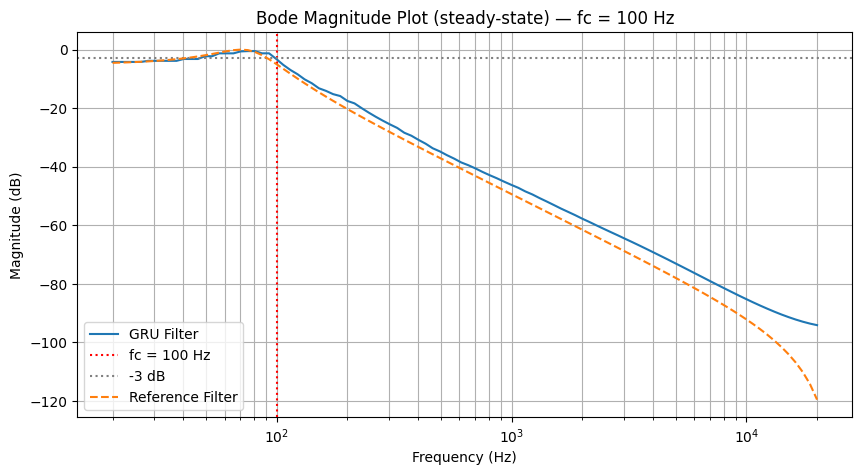

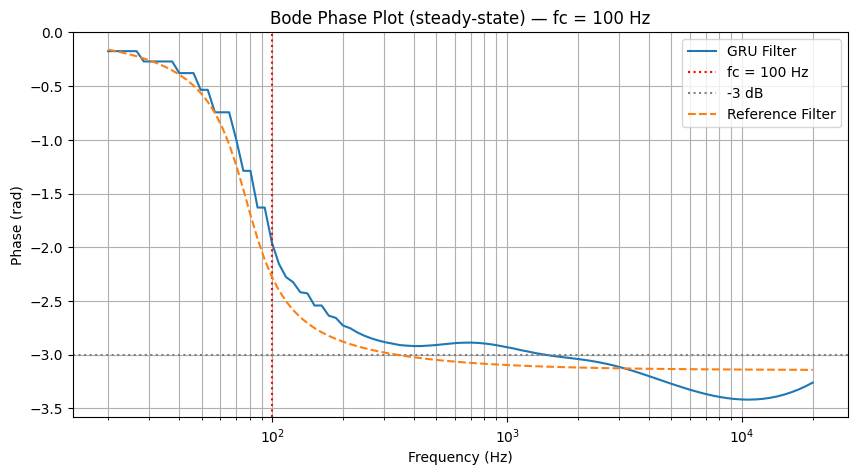

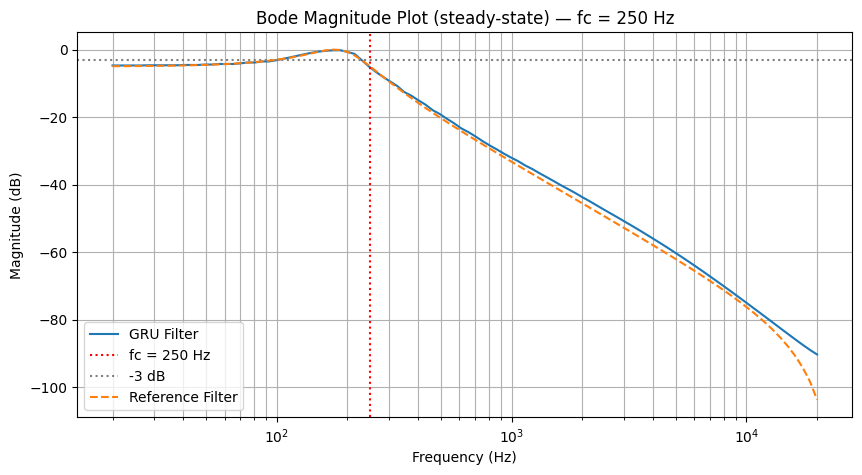

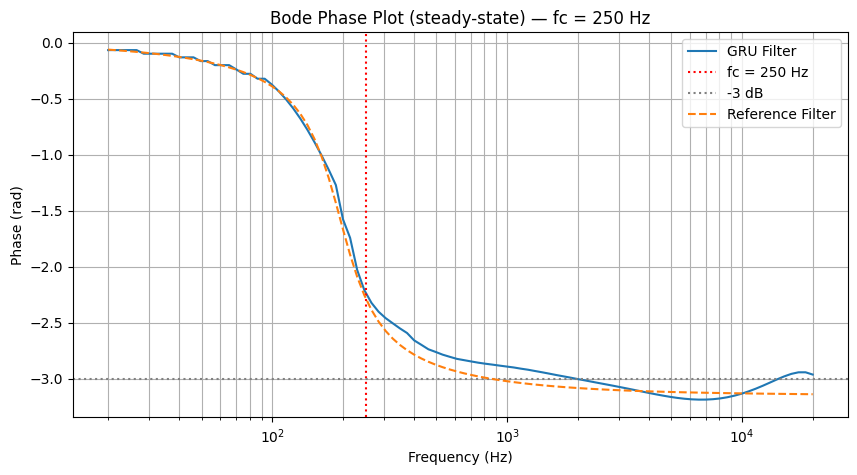

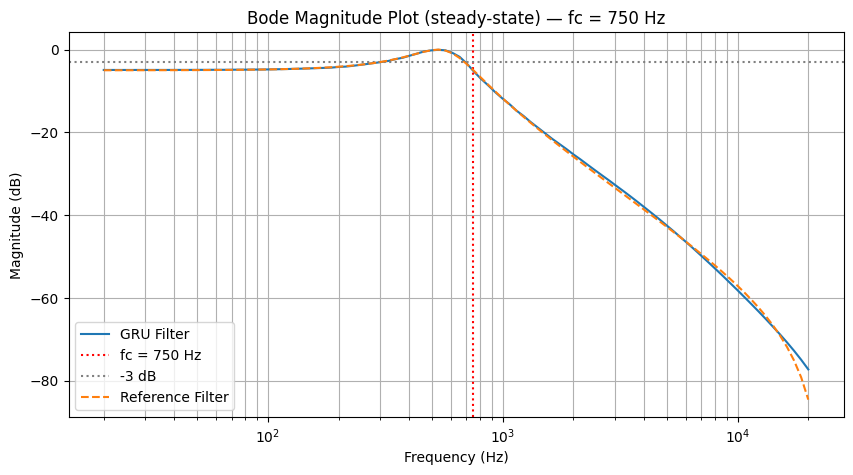

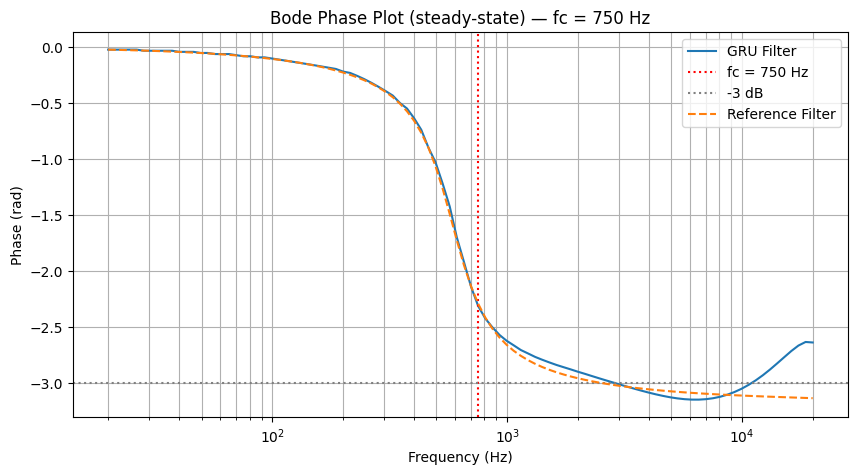

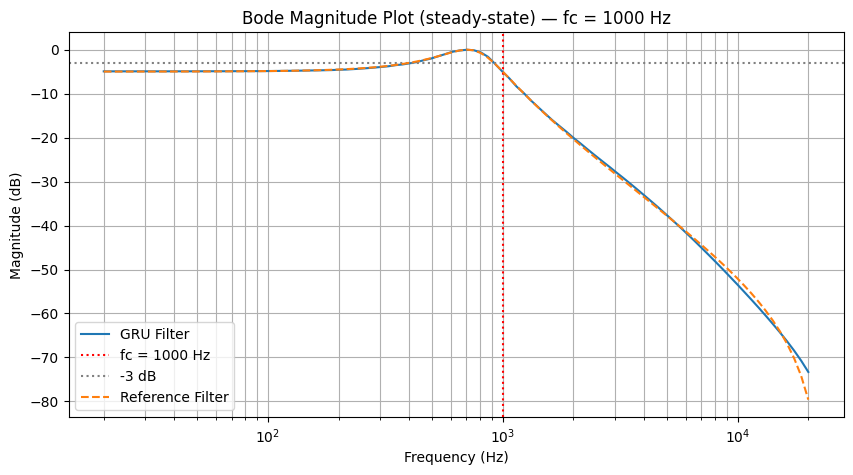

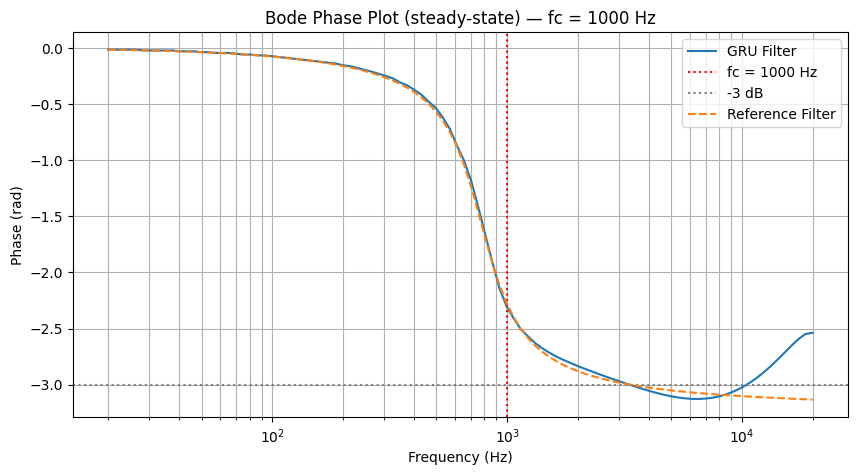

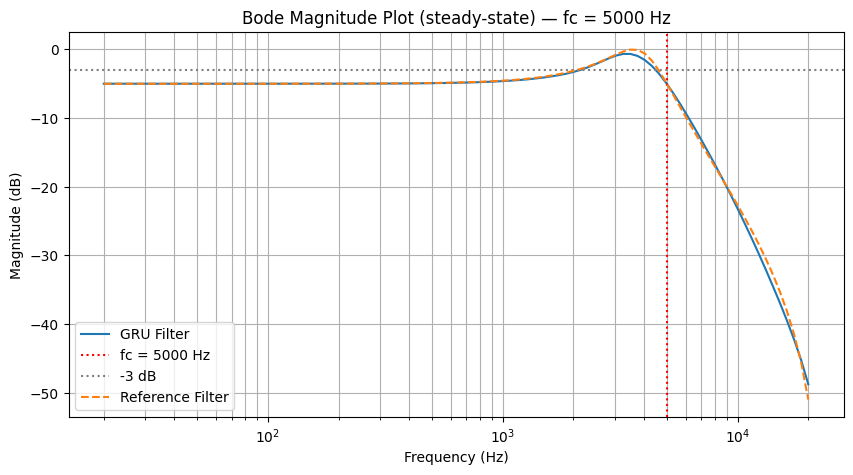

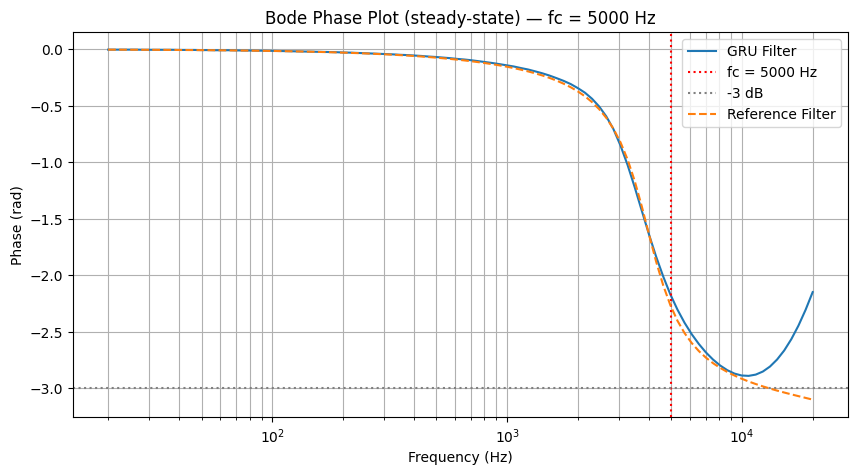

In [ ]:
import torch
import importlib
import analysis_tools as at

importlib.reload(at)

#### Adapt the following parameters to your model ####
hidden_size = 128
num_layers = 2
buffer_size = 512
sample_rate = 48000

filter_algo="cheby1"
order = 2
filter_type = "lowpass"
ripple = 5
######################################################

state = torch.load("order2/lowpass_rnn.pt", map_location=torch.device("cpu"))

filter_rnn = LowpassRNN(hidden_size, num_layers)
try:
    filter_rnn.load_state_dict(state)
except Exception:
    # The model was compiled during training, so the ckpt keys are different
    try:
        state_dict = {
            k.replace("_orig_mod.", ""): v
            for k, v in state["model_state_dict"].items()
        }
        filter_rnn.load_state_dict(state_dict)
    except Exception:
        state_dict = {
            k.replace("_orig_mod.", ""): v for k, v in state.items()
        }
        filter_rnn.load_state_dict(state_dict)
filter_rnn.eval()


for fc in [100, 250, 750, 1000, 5000]:
    print(fc)
    fig, axes = at.plot_bode_GRU(filter_rnn, fc, buffer_size, sample_rate, show=False,plot_type="gain")

    if filter_algo == "cheby1":
        at.plot_cheby_into(axes, fc, order, ripple, sample_rate, plot_type="gain", filter_type=filter_type)
    else:
        at.plot_butter_worth_into(
            axes,
            fc,
            order,
            sample_rate,
            plot_type="gain",
            filter_type=filter_type,
        )
    axes.legend()
    fig.show()

    fig, axes = at.plot_bode_GRU(
        filter_rnn, fc, buffer_size, sample_rate, show=False, plot_type="phase"
    )
    if filter_algo == "cheby1":
        at.plot_cheby_into(
            axes,
            fc,
            order,
            ripple,
            sample_rate,
            plot_type="phase",
            filter_type=filter_type,
        )
    else:
        at.plot_butter_worth_into(
            axes,
            fc,
            order,
            sample_rate,
            plot_type="phase",
            filter_type=filter_type,
        )
    axes.legend()
    fig.show()

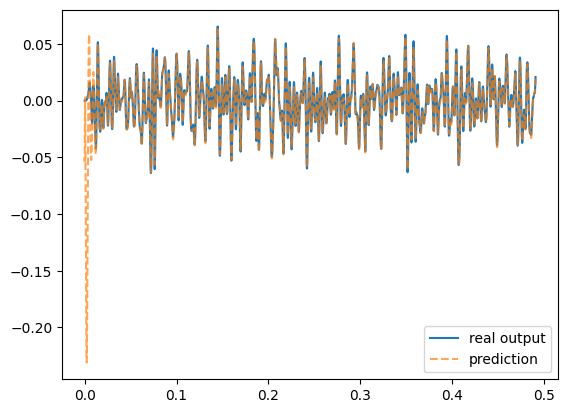

In [38]:
from torch import Tensor
from torch import nn
from create_dataset import exponential_sweep, normalize_freq, bandlimited_white_noise
from scipy.signal import cheby1, filtfilt
data_idx = 5
buffer_size = 512
dataset_folder = "dataset-0"

fc = 250
x = bandlimited_white_noise(24000, sample_rate, 20, sample_rate/2 * 0.99, False)
fc_norm = normalize_freq(fc, sample_rate)

b, a = cheby1(order, ripple, fc, btype="low", fs=sample_rate)

y_pred = run_inference(
    filter_rnn, x, fc_norm=fc_norm, buffer_size=buffer_size, sample_rate=sample_rate
)

import matplotlib.pyplot as plt
from scipy.signal import lfilter

y = lfilter(b, a, x).astype(np.float32)

N = len(y_pred)
t = np.linspace(0, N / sample_rate, N)

plt.figure()
# plt.plot(t, x[:N], label="input")
plt.plot(t, y[:N], label="real output")
plt.plot(t, y_pred, label="prediction", linestyle="--", alpha=0.7)
plt.legend(loc="best")
plt.show()

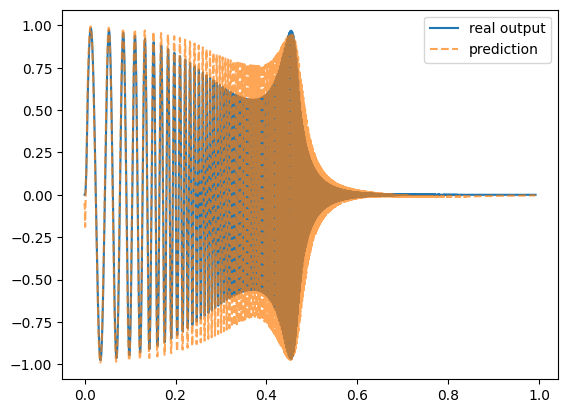

In [39]:
from torch import Tensor
from torch import nn
from create_dataset import exponential_sweep, normalize_freq, bandlimited_white_noise
from scipy.signal import cheby1, filtfilt

data_idx = 5
buffer_size = 512
dataset_folder = "dataset-0"

fc = 500
fc_norm = normalize_freq(fc, sample_rate)

x = exponential_sweep(48000, 20, 18765, 48000)

b, a = cheby1(order, 5, fc, btype="low", fs=sample_rate)

y_pred = run_inference(
    filter_rnn, x, fc_norm=fc_norm, buffer_size=buffer_size, sample_rate=sample_rate
)

import matplotlib.pyplot as plt
from scipy.signal import lfilter

y = lfilter(b, a, x).astype(np.float32)

N = len(y_pred)
t = np.linspace(0, N / sample_rate, N)

plt.figure()
# plt.plot(t, x[:N], label="input")
plt.plot(t, y[:N], label="real output")
plt.plot(t, y_pred, label="prediction", linestyle="--", alpha=0.7)
plt.legend(loc="best")
plt.show()

## ONNX Runtime inference test

In [ ]:
import onnx

model = onnx.load("lowpass_rnn2.onnx")
for inp in model.graph.input:
    print(inp.name, inp.type.tensor_type.shape)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import onnxruntime as ort
import numpy as np

hidden_size = 64
num_layers = 2
buffer_size = 96
sample_rate = 48000

state = torch.load("lowpass_rnn.pt", map_location=torch.device("cpu"))
filter_rnn = LowpassRNN(hidden_size, num_layers)
filter_rnn.load_state_dict(state)
filter_rnn.eval()

input_idx = 9
dataset_idx = 10
x = np.load("dataset-{}/inputs/input-{}.npy".format(dataset_idx, input_idx))
y = np.load("dataset-{}/expected/expected-{}.npy".format(dataset_idx, input_idx))

y_pred = np.load("onnx_inference_test/output-{}.npy".format(input_idx))
y_pred_py = run_inference(
    filter_rnn, x[:-1], fc_norm=x[-1], buffer_size=96, sample_rate=sample_rate
)

print(x.shape)
print(y.shape)
print(y_pred.shape)
t = np.arange(len(y))
m = min(len(t), len(y_pred))

plt.figure()
plt.plot(t, x[:m], label="signal")
plt.plot(t, y, label="filtered signal")
plt.plot(t[:m], y_pred[:m], label="predicted filtered signal (onnx)")
plt.plot(t[:m], y_pred_py[:m], label="predicted filtered signal (pytorch)")
plt.legend(loc="lower left")
plt.show()